# 25 - Intermediate Fusion Front-Only 4-Class

**Dataset:** Front-only 4-Class
**3 Skenario:** B1 (Baseline), B2 (Class Weights), B3 (Weights + Augmentasi)

In [1]:
import sys, os, json
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
from torch.utils.data import DataLoader
from collections import Counter

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from training.models import IntermediateFusion
from training.utils import (
    EmotionImageDataset, EmotionLandmarkDataset, EmotionMultimodalDataset,
    get_class_weights, train_model, full_evaluation,
    plot_training_history, plot_confusion_matrix, plot_per_class_f1
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)})")

Device: cuda
GPU: Tesla T4)


In [2]:
DATASET_DIR = PROJECT_ROOT / "data" / "dataset_frontonly_4class"
DATASET_AUG_DIR = PROJECT_ROOT / "data" / "dataset_frontonly_4class_augmented"
OUTPUT_DIR = PROJECT_ROOT / "models" / "frontonly" / "4class"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BATCH_SIZE = 32
EPOCHS = 50
LR = 0.0001
PATIENCE = 15
NUM_CLASSES = 4
EMOTIONS = ["neutral", "happy", "sad", "negative"]

print(f"Dataset: {DATASET_DIR}")
print(f"Output: {OUTPUT_DIR}")

Dataset: /home/bs000716/MOTHER-TANK/TRAIN/data/dataset_frontonly_4class
Output: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly/4class


In [3]:
print("Loading multimodal data...")
def load_dataloaders(dataset_dir, batch_size=32):
    train_ds = EmotionMultimodalDataset(
        dataset_dir / "X_train_images.npy", dataset_dir / "X_train_landmarks.npy", dataset_dir / "y_train.npy")
    val_ds = EmotionMultimodalDataset(
        dataset_dir / "X_val_images.npy", dataset_dir / "X_val_landmarks.npy", dataset_dir / "y_val.npy")
    test_ds = EmotionMultimodalDataset(
        dataset_dir / "X_test_images.npy", dataset_dir / "X_test_landmarks.npy", dataset_dir / "y_test.npy")
    train_l = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_l = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_l = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    y = np.load(dataset_dir / "y_train.npy")
    counts = Counter(y.tolist())
    print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
    for i, e in enumerate(EMOTIONS): print(f"  {e:>10s}: {counts.get(i, 0)}")
    return train_l, val_l, test_l

train_loader, val_loader, test_loader = load_dataloaders(DATASET_DIR, BATCH_SIZE)

Loading multimodal data...


Train: 5348 | Val: 707 | Test: 1036
     neutral: 4192
       happy: 660
         sad: 382
    negative: 114


## Skenario B1: Baseline

Model parameters: 52,465,700

Training INTERMEDIATE B1 - Baseline (Front-Only)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      0.9939     0.6402     0.9437    0.9349   0.2416   0.000100  (32.9s)


     2      0.7297     0.7809     0.7976    0.9335   0.2414   0.000100  (32.4s)


     3      0.6771     0.7840     0.7567    0.8062   0.2365   0.000100  (32.4s)


     4      0.6339     0.7876     0.5483    0.9052   0.2505   0.000100  (32.5s)


...

    17      0.4170     0.8547     0.4146    0.9052   0.3987   0.000050  (31.6s)


    18      0.4161     0.8525     0.5200    0.7100   0.3324   0.000050  (31.6s)


    19      0.4069     0.8555     0.4755    0.8048   0.3392   0.000050  (31.6s)


    20      0.4088     0.8560     0.3772    0.9165   0.4324   0.000050  (31.7s)


    21      0.3928     0.8598     0.4125    0.8713   0.3878   0.000050  (31.7s)

Early stopping at epoch 21. Best epoch: 6 (val_f1=0.4804)

Best: epoch 6, val_acc=0.9547, val_f1=0.4804
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly/4class/intermediate_b1.pth


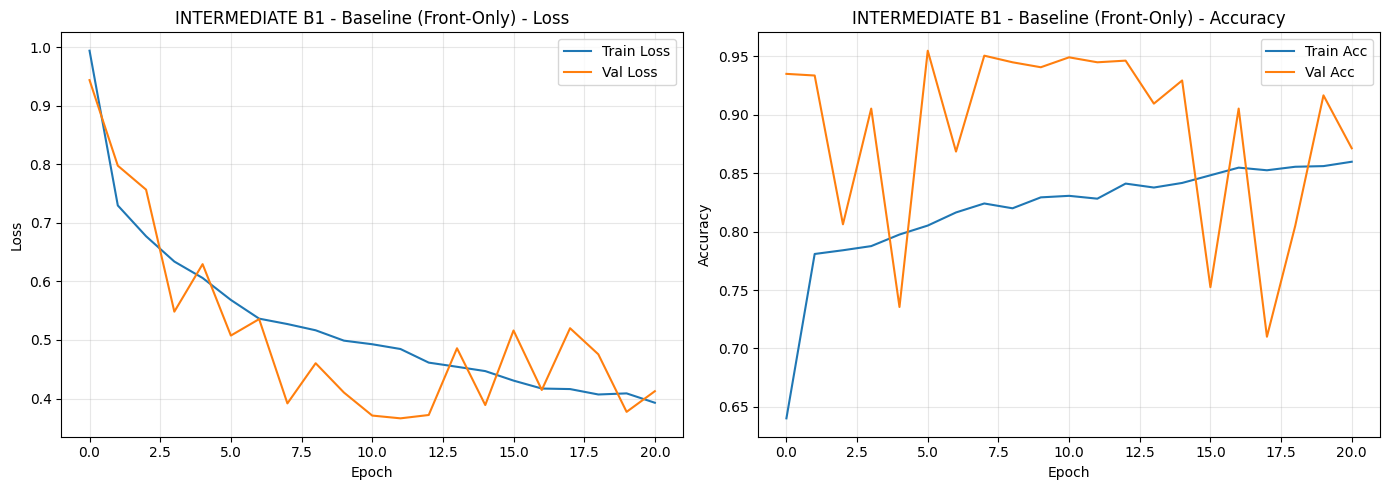

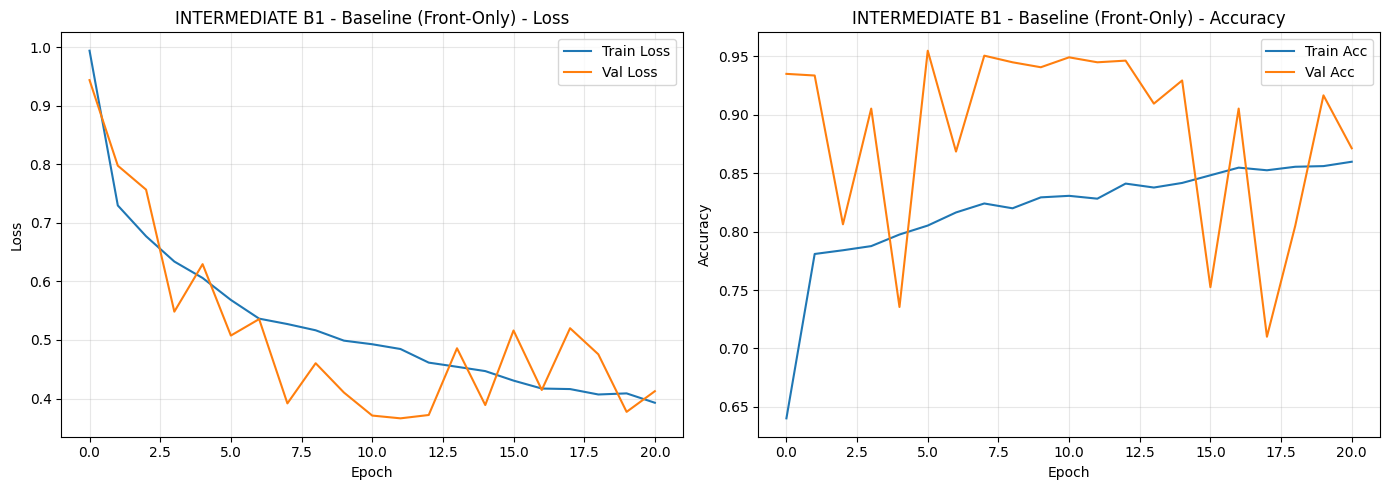

In [4]:
# B1: Baseline
criterion = nn.CrossEntropyLoss()

model = IntermediateFusion(num_classes=NUM_CLASSES).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=8, min_lr=1e-7)

print("\nTraining INTERMEDIATE B1 - Baseline (Front-Only)...")
history, best_epoch = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler,
    device, model_type="fusion", epochs=EPOCHS, patience=PATIENCE,
    save_path=str(OUTPUT_DIR / "intermediate_b1.pth"))

plot_training_history(history, "INTERMEDIATE B1 - Baseline (Front-Only)")

EVALUASI B1 - BASELINE


Test Loss: 0.4101
Test Accuracy: 0.9431
Test Macro F1: 0.2427
Test Weighted F1: 0.9192

Classification Report:
              precision    recall  f1-score   support

     neutral       0.95      1.00      0.97       981
       happy       0.00      0.00      0.00        10
         sad       0.00      0.00      0.00        29
    negative       0.00      0.00      0.00        16

    accuracy                           0.94      1036
   macro avg       0.24      0.25      0.24      1036
weighted avg       0.90      0.94      0.92      1036



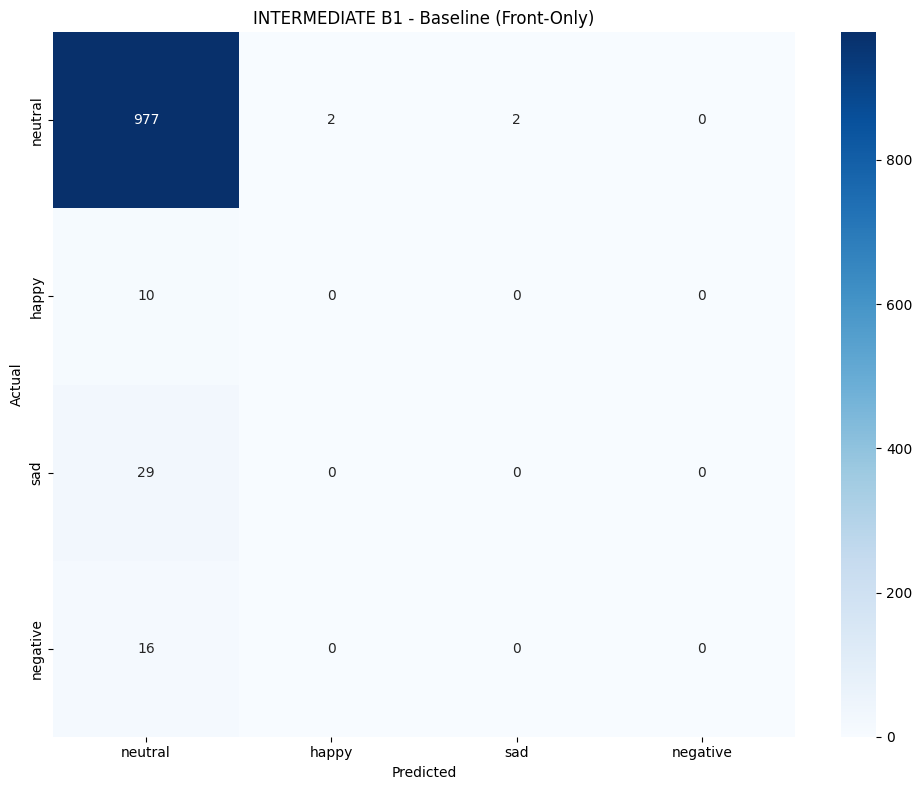

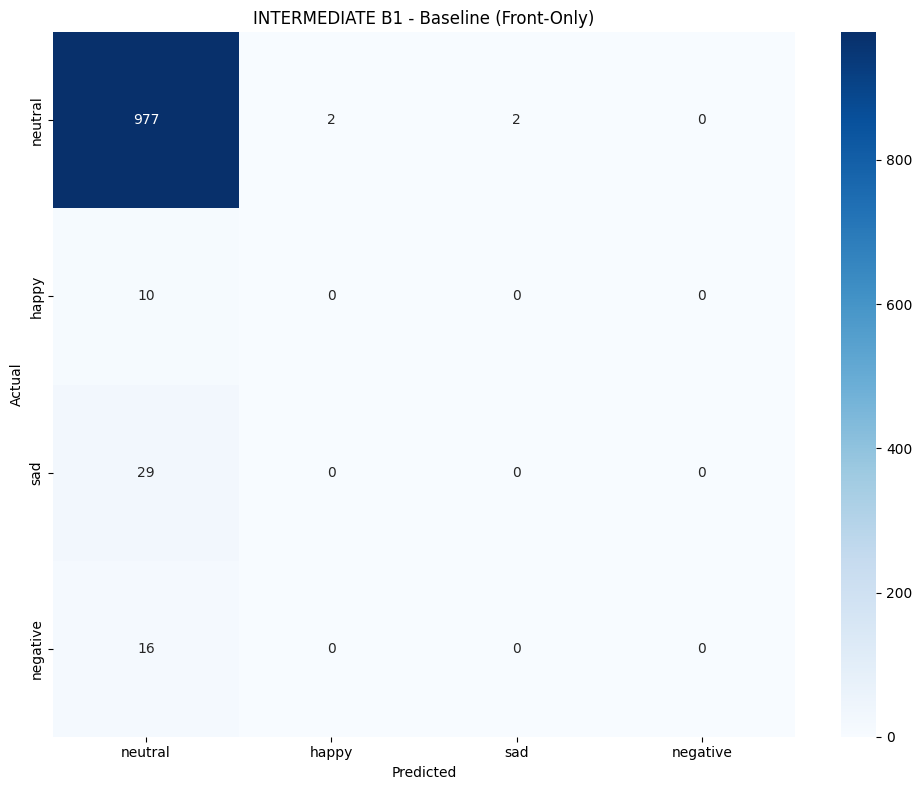

In [5]:
# Evaluate B1
model.load_state_dict(torch.load(OUTPUT_DIR / "intermediate_b1.pth", map_location=device, weights_only=True))
print("=" * 60)
print("EVALUASI B1 - BASELINE")
print("=" * 60)
results_b1 = full_evaluation(model, test_loader, criterion, device, "fusion", EMOTIONS)
plot_confusion_matrix(results_b1["confusion_matrix"], "INTERMEDIATE B1 - Baseline (Front-Only)", emotions=EMOTIONS)

## Skenario B2: Class Weights

Class weights: None


Model parameters: 52,465,700

Training INTERMEDIATE B2 - Class Weights (Front-Only)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      0.9919     0.6518     0.7926    0.9378   0.2420   0.000100  (31.7s)


     2      0.7303     0.7801     0.6637    0.9378   0.2420   0.000100  (31.7s)


     3      0.6625     0.7835     0.7090    0.9194   0.2542   0.000100  (31.7s)


...

    21      0.3531     0.8723     0.4070    0.8996   0.3961   0.000050  (31.6s)


    22      0.3469     0.8691     0.4753    0.8218   0.3535   0.000050  (31.6s)


    23      0.3393     0.8777     0.5440    0.7482   0.3202   0.000050  (31.6s)


    24      0.3317     0.8807     0.5404    0.7369   0.3188   0.000050  (31.6s)


    25      0.3210     0.8826     0.4091    0.8996   0.3874   0.000050  (31.6s)

Early stopping at epoch 25. Best epoch: 10 (val_f1=0.4646)

Best: epoch 10, val_acc=0.9236, val_f1=0.4646
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly/4class/intermediate_b2.pth


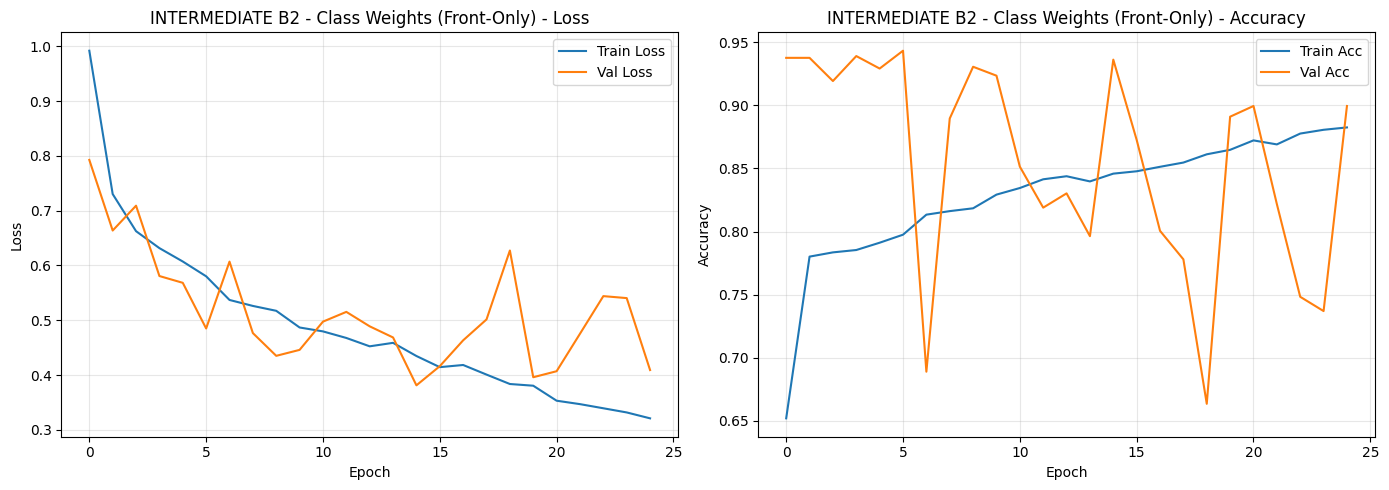

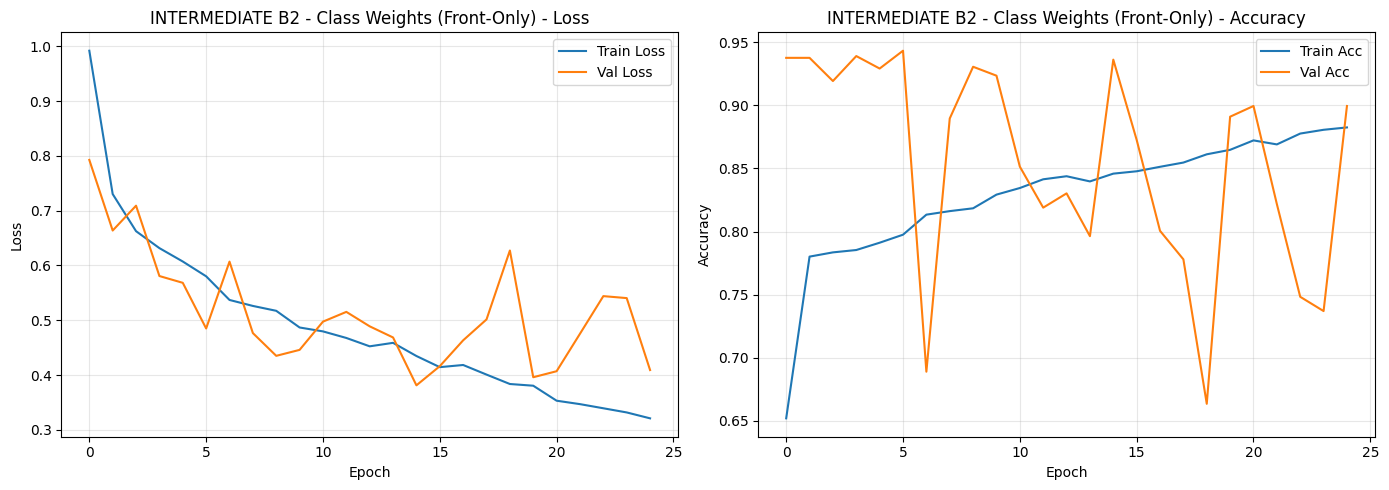

In [6]:
# B2: Class Weights
weights = get_class_weights(DATASET_DIR, device)
print(f"Class weights: {weights}")
criterion = nn.CrossEntropyLoss(weight=weights)

model = IntermediateFusion(num_classes=NUM_CLASSES).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=8, min_lr=1e-7)

print("\nTraining INTERMEDIATE B2 - Class Weights (Front-Only)...")
history, best_epoch = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler,
    device, model_type="fusion", epochs=EPOCHS, patience=PATIENCE,
    save_path=str(OUTPUT_DIR / "intermediate_b2.pth"))

plot_training_history(history, "INTERMEDIATE B2 - Class Weights (Front-Only)")

EVALUASI B2 - CLASS WEIGHTS


Test Loss: 0.5002
Test Accuracy: 0.8745
Test Macro F1: 0.2689
Test Weighted F1: 0.8923

Classification Report:
              precision    recall  f1-score   support

     neutral       0.96      0.92      0.94       981
       happy       0.02      0.20      0.04        10
         sad       0.14      0.07      0.09        29
    negative       0.00      0.00      0.00        16

    accuracy                           0.87      1036
   macro avg       0.28      0.30      0.27      1036
weighted avg       0.91      0.87      0.89      1036



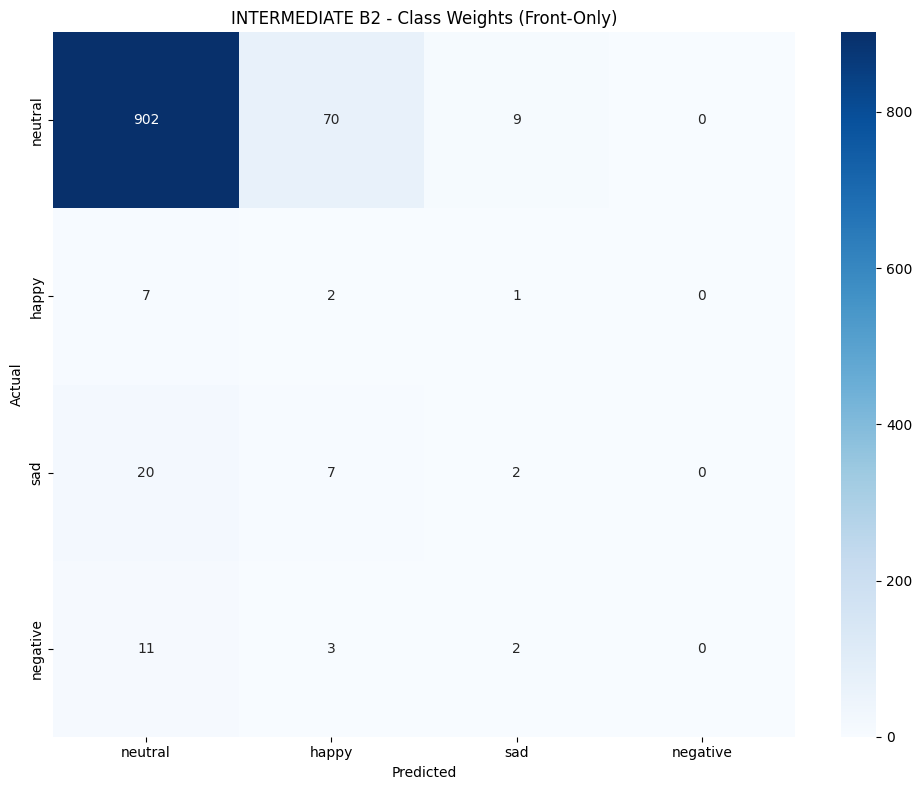

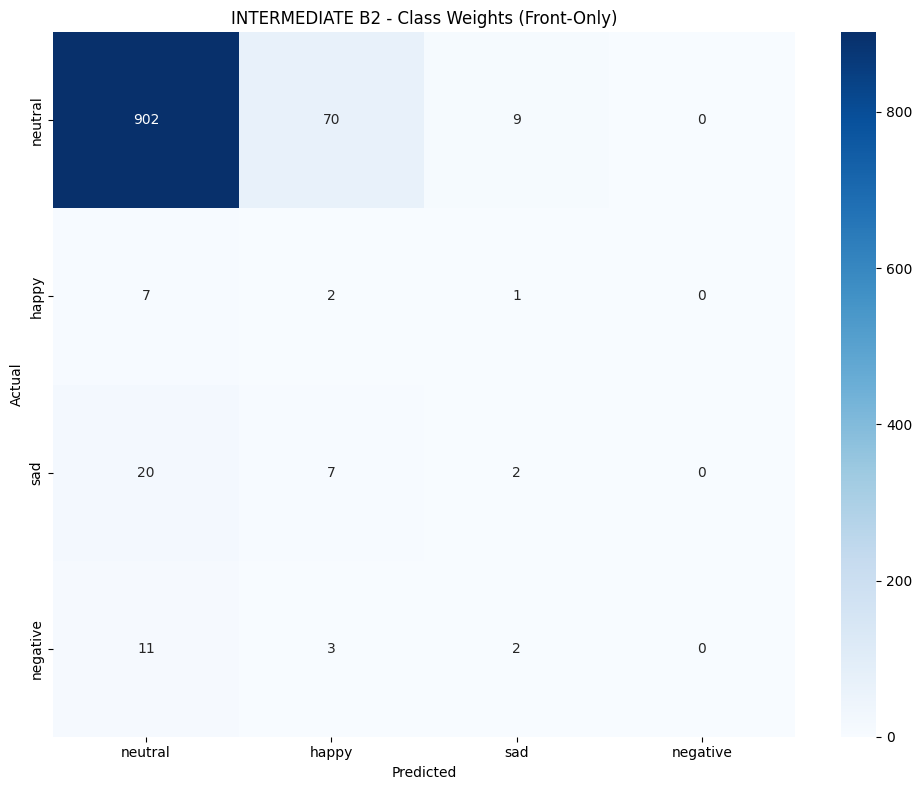

In [7]:
# Evaluate B2
model.load_state_dict(torch.load(OUTPUT_DIR / "intermediate_b2.pth", map_location=device, weights_only=True))
print("=" * 60)
print("EVALUASI B2 - CLASS WEIGHTS")
print("=" * 60)
results_b2 = full_evaluation(model, test_loader, criterion, device, "fusion", EMOTIONS)
plot_confusion_matrix(results_b2["confusion_matrix"], "INTERMEDIATE B2 - Class Weights (Front-Only)", emotions=EMOTIONS)

## Skenario B3: Class Weights + Augmentasi

Train: 5834 | Val: 707 | Test: 1036
     neutral: 4192
       happy: 660
         sad: 382
    negative: 600
Augmented class weights: None


Model parameters: 52,465,700

Training INTERMEDIATE B3 - Weights + Augmentasi (Front-Only)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.0462     0.6099     0.6878    0.9364   0.2418   0.000100  (35.3s)


     2      0.8194     0.7333     0.4552    0.9349   0.2416   0.000100  (35.8s)


     3      0.7501     0.7479     0.5000    0.9364   0.2418   0.000100  (35.8s)


...

    33      0.1579     0.9434     0.5254    0.8105   0.3264   0.000025  (35.5s)


    34      0.1560     0.9463     0.6065    0.7751   0.3235   0.000025  (35.7s)


    35      0.1593     0.9465     0.4514    0.8600   0.3447   0.000025  (35.6s)


    36      0.1493     0.9491     0.5745    0.7878   0.3198   0.000025  (35.5s)


    37      0.1508     0.9455     0.4228    0.8812   0.3710   0.000025  (35.6s)

Early stopping at epoch 37. Best epoch: 22 (val_f1=0.4307)

Best: epoch 22, val_acc=0.9321, val_f1=0.4307
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly/4class/intermediate_b3.pth


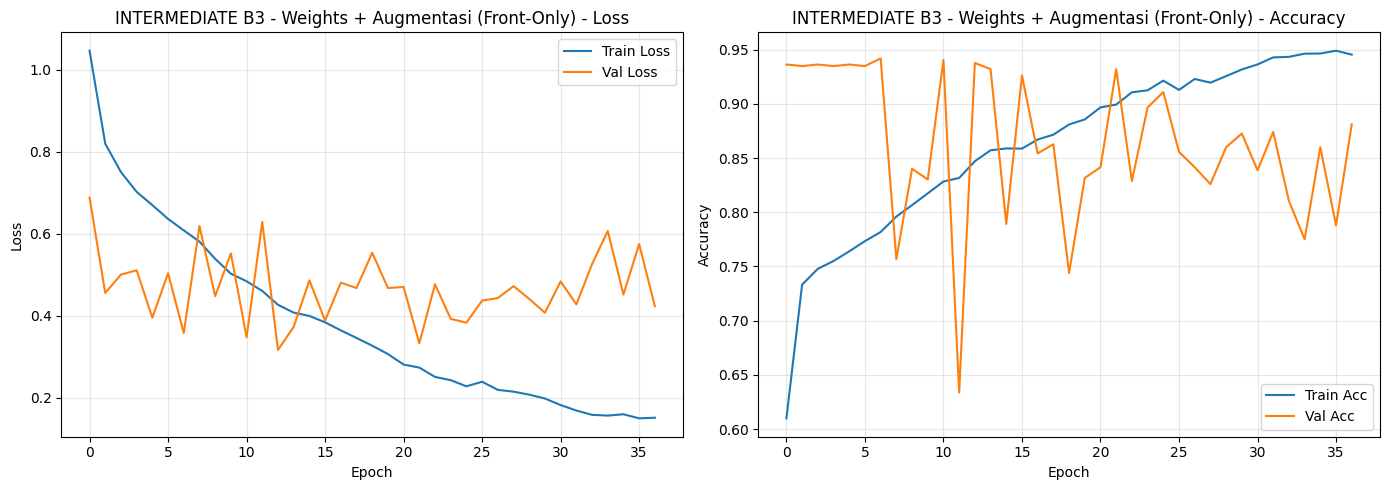

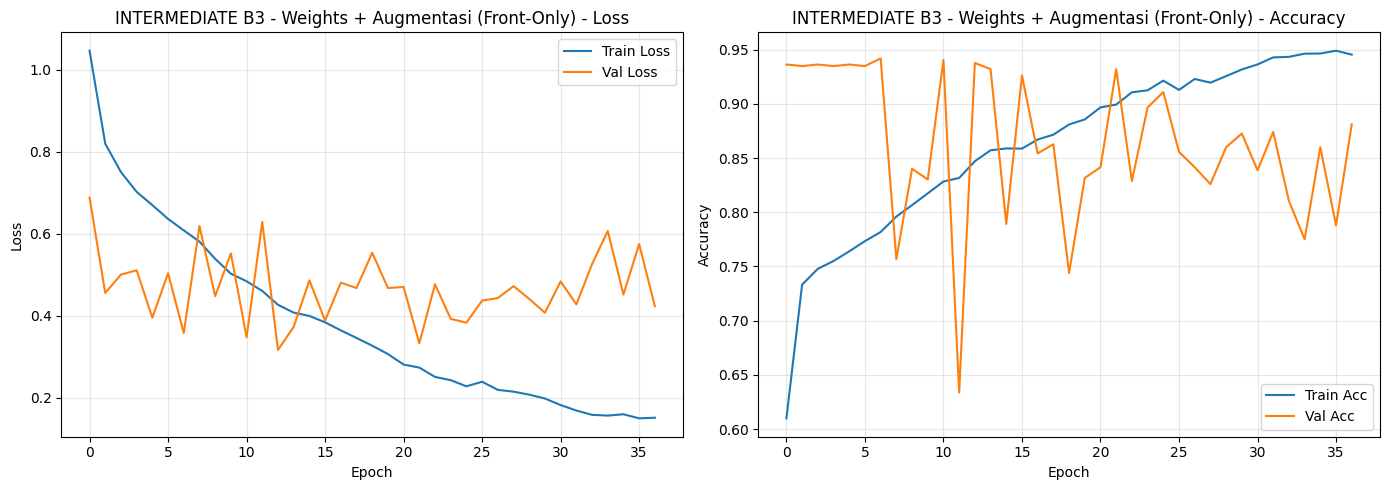

In [8]:
# B3: Weights + Augmentasi
train_loader_aug, _, _ = load_dataloaders(DATASET_AUG_DIR, BATCH_SIZE)
weights_aug = get_class_weights(DATASET_AUG_DIR, device)
print(f"Augmented class weights: {weights_aug}")
criterion = nn.CrossEntropyLoss(weight=weights_aug)

model = IntermediateFusion(num_classes=NUM_CLASSES).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=8, min_lr=1e-7)

print("\nTraining INTERMEDIATE B3 - Weights + Augmentasi (Front-Only)...")
history, best_epoch = train_model(
    model, train_loader_aug, val_loader, criterion, optimizer, scheduler,
    device, model_type="fusion", epochs=EPOCHS, patience=PATIENCE,
    save_path=str(OUTPUT_DIR / "intermediate_b3.pth"))

plot_training_history(history, "INTERMEDIATE B3 - Weights + Augmentasi (Front-Only)")

EVALUASI B3 - WEIGHTS + AUGMENTASI


Test Loss: 0.3776
Test Accuracy: 0.9073
Test Macro F1: 0.2385
Test Weighted F1: 0.9032

Classification Report:
              precision    recall  f1-score   support

     neutral       0.95      0.96      0.95       981
       happy       0.00      0.00      0.00        10
         sad       0.00      0.00      0.00        29
    negative       0.00      0.00      0.00        16

    accuracy                           0.91      1036
   macro avg       0.24      0.24      0.24      1036
weighted avg       0.90      0.91      0.90      1036



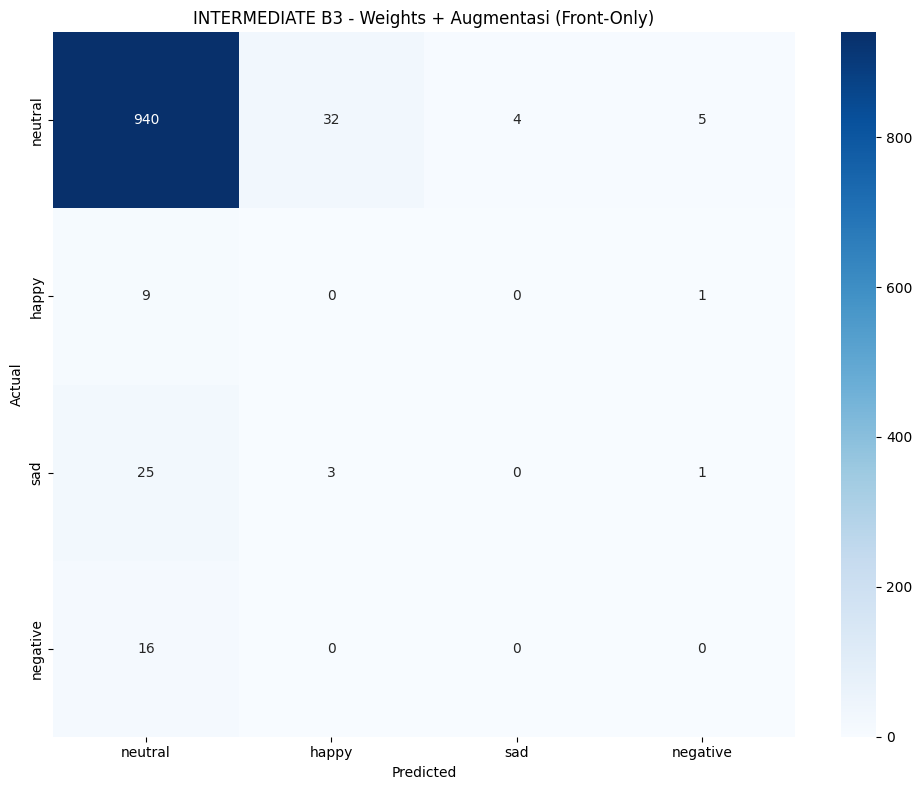

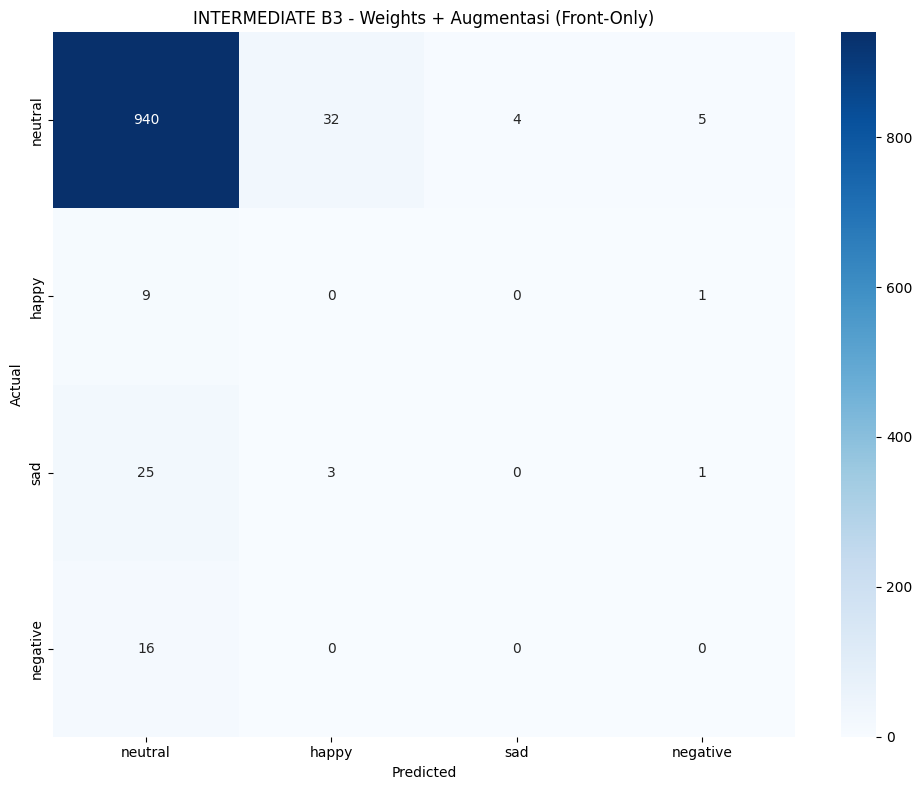

In [9]:
# Evaluate B3
model.load_state_dict(torch.load(OUTPUT_DIR / "intermediate_b3.pth", map_location=device, weights_only=True))
print("=" * 60)
print("EVALUASI B3 - WEIGHTS + AUGMENTASI")
print("=" * 60)
results_b3 = full_evaluation(model, test_loader, criterion, device, "fusion", EMOTIONS)
plot_confusion_matrix(results_b3["confusion_matrix"], "INTERMEDIATE B3 - Weights + Augmentasi (Front-Only)", emotions=EMOTIONS)

## Perbandingan 3 Skenario

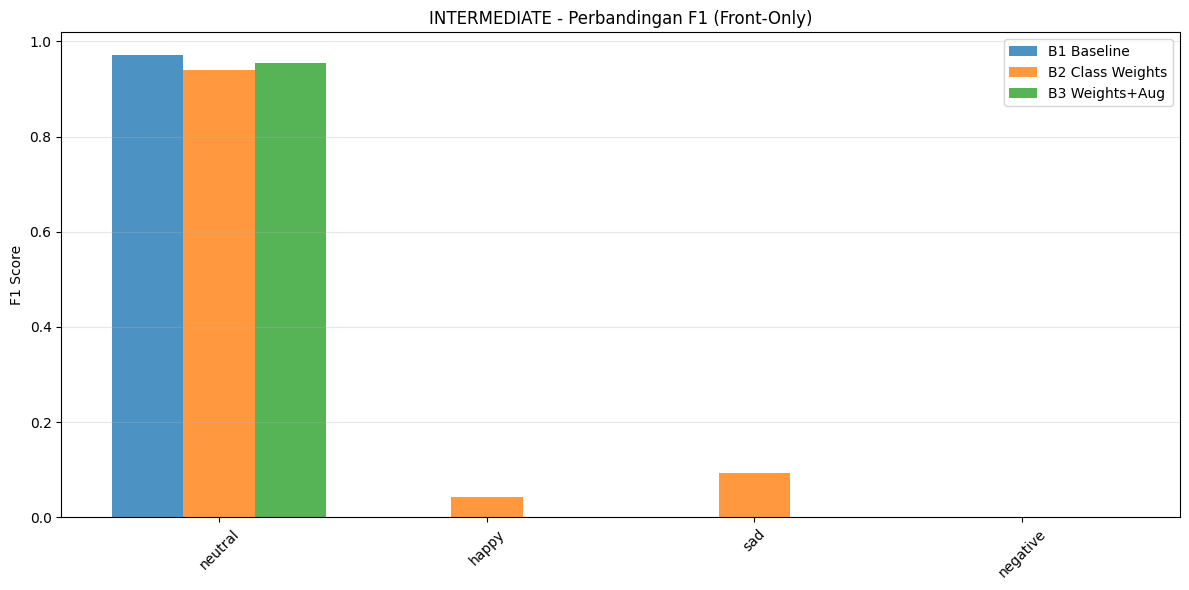

RINGKASAN INTERMEDIATE FRONT-ONLY
Skenario                    Accuracy   Macro F1  Weighted F1
----------------------------------------------------------------------
B1 Baseline                   0.9431     0.2427       0.9192
B2 Class Weights              0.8745     0.2689       0.8923
B3 Weights+Aug                0.9073     0.2385       0.9032

Saved to /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly/4class/intermediate_results.json


In [10]:
# Perbandingan
all_results = {
    "B1 Baseline": results_b1,
    "B2 Class Weights": results_b2,
    "B3 Weights+Aug": results_b3,
}
plot_per_class_f1(all_results, "INTERMEDIATE - Perbandingan F1 (Front-Only)", emotions=EMOTIONS)

print("=" * 70)
print("RINGKASAN INTERMEDIATE FRONT-ONLY")
print("=" * 70)
print(f"{'Skenario':<25} {'Accuracy':>10} {'Macro F1':>10} {'Weighted F1':>12}")
print("-" * 70)
for name, r in all_results.items():
    print(f"{name:<25} {r['test_accuracy']:>10.4f} {r['test_macro_f1']:>10.4f} {r['test_weighted_f1']:>12.4f}")

results_save = {}
for name, r in all_results.items():
    results_save[name] = {
        "accuracy": float(r["test_accuracy"]),
        "macro_f1": float(r["test_macro_f1"]),
        "weighted_f1": float(r["test_weighted_f1"]),
    }
with open(OUTPUT_DIR / "intermediate_results.json", "w") as f:
    json.dump(results_save, f, indent=2)
print(f"\nSaved to {OUTPUT_DIR / 'intermediate_results.json'}")